# **Step1_AI 강사 Agent v1.0**

## **0. 미션**

### 미션① : AI 강의 영상 제작 단계별 구축하기
* State 정의
* 1page ppt 파일 인식  텍스트, 표, 그림 저장
* 정보 분석 : 텍스트, 표, 그림 등 정보로 부터 내용 정리(LLM)
* 설명 흐름 정리 및 설명문 생성(LLM)




### 미션② : AI 강의 영상 제작 전체 흐름 엮어내기
* 설명문을 음성으로 변환(TTS)
* 음성과 슬라이드 스냅샷 이미지 합성하여 영상 제작하기
* 전체를 Agent 그래프로 엮기


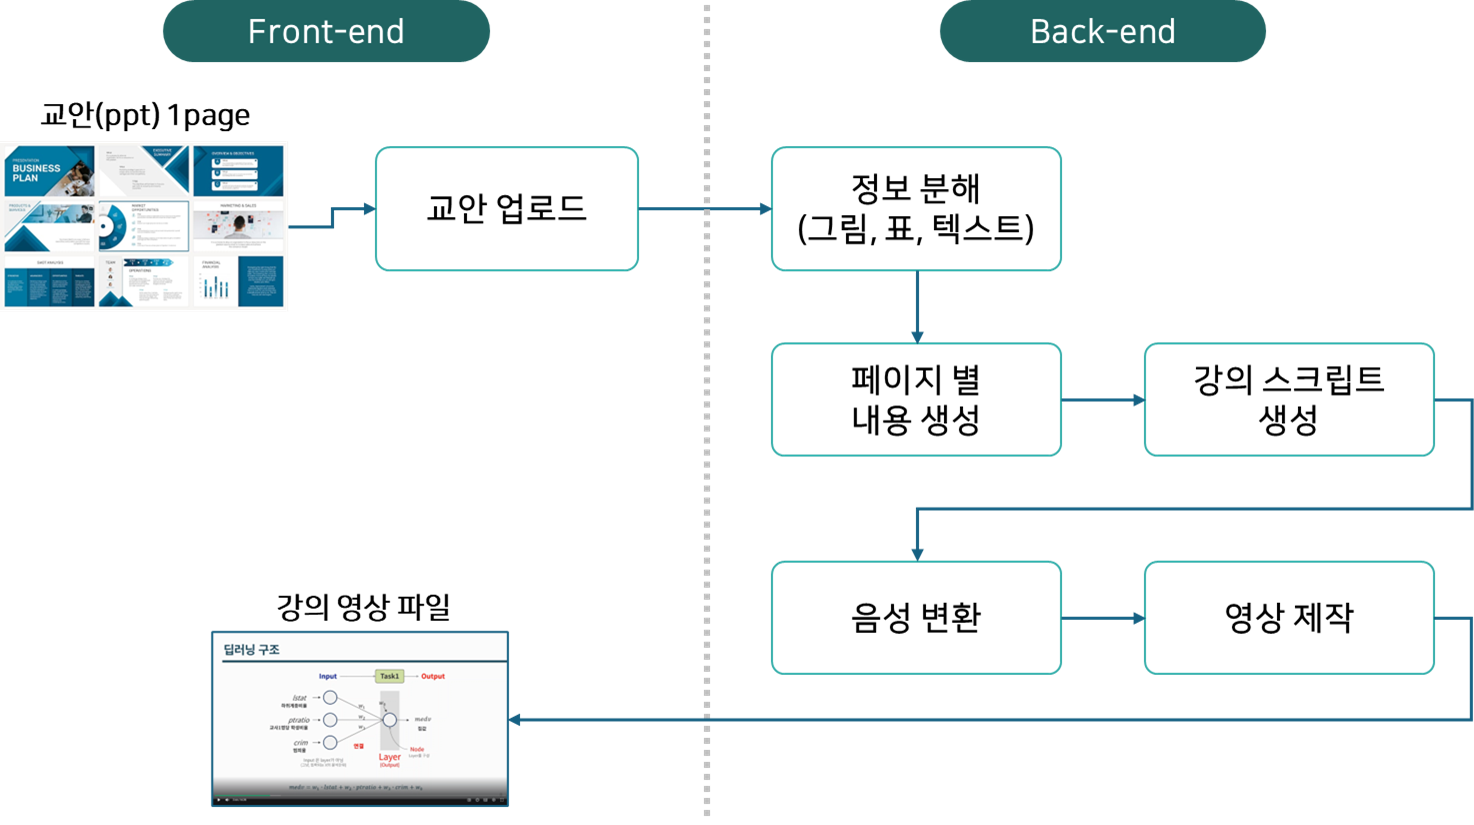

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
	* 새 폴더(project_multi_modal)를 생성하고
	* 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (2) 한글 폰트 준비
* 한글 폰트 설치 및 설정 코드
* 영상 제작 등 한글 사용시 필요

In [ ]:
!apt-get -y install ffmpeg libreoffice poppler-utils poppler-data locales \
				   fonts-noto-cjk fonts-noto-cjk-extra fonts-nanum fonts-unfonts-core
!sed -i 's/^# *ko_KR.UTF-8 UTF-8/ko_KR.UTF-8 UTF-8/' /etc/locale.gen
!locale-gen ko_KR.UTF-8
!update-locale LANG=ko_KR.UTF-8
!fc-cache -fv

In [ ]:
%%bash
mkdir -p ~/.config/fontconfig
cat > ~/.config/fontconfig/fonts.conf <<'EOF'
<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>

	<!-- ▷ 한국어 텍스트엔 Noto Sans CJK KR을 우선 사용 -->
	<match target="pattern">
		<test name="lang" compare="eq"><string>ko</string></test>
		<edit name="family" mode="prepend" binding="strong">
			<string>Noto Sans CJK KR</string>
		</edit>
	</match>

	<!-- ▷ 일반 가족명에도 기본 대체 추가 -->
	<alias><family>sans-serif</family><prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>serif</family><prefer><family>Noto Serif CJK KR</family></prefer></alias>
	<alias><family>monospace</family><prefer><family>Noto Sans Mono CJK KR</family></prefer></alias>

	<!-- ▷ Windows/macOS/웹에서 흔한 한글 폰트들을 Noto로 매핑 -->
	<alias><family>Malgun Gothic</family>        <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>맑은 고딕</family>             <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Apple SD Gothic Neo</family>  <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>AppleGothic</family>          <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Pretendard</family>           <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Pretendard Variable</family>  <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>NanumSquare</family>          <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Spoqa Han Sans</family>       <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>KoPub</family>                <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Gulim</family>                <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Dotum</family>                <prefer><family>Noto Sans CJK KR</family></prefer></alias>
	<alias><family>Batang</family>               <prefer><family>Noto Serif CJK KR</family></prefer></alias>
</fontconfig>
EOF
fc-cache -fv


### (3) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
!apt-get -y install ffmpeg libreoffice poppler-utils
!pip install python-pptx pillow langgraph -q

* 라이브러리 로딩

In [1]:
import os, re, textwrap, subprocess, json, base64, mimetypes, shlex
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Optional, TypedDict
from PIL import Image, ImageDraw
from pptx import Presentation
from pptx.enum.shapes import MSO_SHAPE_TYPE
from openai import OpenAI
# from google.colab import files
from IPython.display import Audio, display, Video

# 추가 라이브러리
from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser, CommaSeparatedListOutputParser
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph, START, END

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### (4) OpenAI API Key 확인
* 구글드라이브에 생성한 폴더 'project_multi_modal'에서
* api_key.txt 파일 안에 각자 발급 받은 openai api key를 저장합니다.

In [2]:
def load_api_keys(filepath="api_key.txt"):
	with open(filepath, "r") as f:
		for line in f:
			line = line.strip()
			if line and "=" in line:
				key, value = line.split("=", 1)
				os.environ[key.strip()] = value.strip()

path = '../'
# API 키 로드 및 환경변수 설정
load_api_keys(path + 'API_KEY.env')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [3]:
print(os.environ['OPENAI_API_KEY'][:3])

sk-


### (5) 유용한 함수들 제공
* 다음은 프로젝트를 수행하는데 유용한 함수들입니다.
* 이 함수들의 내용을 확인하고 필요시 활용하여 개인 과제를 수행합니다.(꼭 활용해야 하는 것은 아닙니다.)

* 공백 제거 함수

In [4]:
def clean_text(s):
	return re.sub(r"\s+", " ", s).strip()

In [5]:
# 사용 예
raw_text = " 딥러닝    모델 \n\n 학습에는 \t 많은   데이터가 필요합니다.  "
print("* 원본:", raw_text)
print("* 정제 후:", clean_text(raw_text))

* 원본:  딥러닝    모델 

 학습에는 	 많은   데이터가 필요합니다.  
* 정제 후: 딥러닝 모델 학습에는 많은 데이터가 필요합니다.


* 긴 문자열을 문장 단위로 나누는 문장 분리기

In [5]:
def split_sents(t: str) -> List[str]:
	parts = re.split(r'([\.?!])', t)
	merged = []
	for i in range(0, len(parts)-1, 2):
		sent = (parts[i] + parts[i+1]).strip()
		if sent: merged.append(sent)
	if len(parts) % 2 == 1 and parts[-1].strip():
		merged.append(parts[-1].strip())
	return [s for s in merged if s]

In [7]:
# 사용 예
text = "안녕하세요. 오늘은 날씨가 좋네요! 점심 드셨어요?"
print(split_sents(text))

['안녕하세요.', '오늘은 날씨가 좋네요!', '점심 드셨어요?']


* 오디오 길이 계산

In [6]:
def ffprobe_duration(path: str) -> float:
	out = subprocess.check_output([
		"ffprobe","-v","error","-show_entries","format=duration",
		"-of","default=noprint_wrappers=1:nokey=1", path]).decode().strip()
	return float(out)

In [18]:
# 사용 예
# uploaded = files.upload()   # 로컬 PC에서 '스티브 잡스4.mp3' 선택

mp3_file = "./data/스티브 잡스4.mp3"
duration = ffprobe_duration(mp3_file)
print(f"{mp3_file} 길이: {duration:.2f}초")

./data/스티브 잡스4.mp3 길이: 58.82초


* 이미지를 base64로 변환

In [8]:
def img_to_data_url(path: str) -> str:
	mime = mimetypes.guess_type(path)[0] or "image/png"
	with open(path, "rb") as f:
		b64 = base64.b64encode(f.read()).decode("utf-8")
	return f"data:{mime};base64,{b64}"

In [21]:
# 사용 예
# uploaded = files.upload()   # 로컬 PC에서 'cat_bird.jpg' 선택

png_path = "./data/cat_bird.jpg"
data_url = img_to_data_url(png_path)
print(data_url[:100] + "...")   # 앞부분만 출력 (너무 길기 때문)

data:image/jpeg;base64,/9j/4AAQSkZJRgABAQIASABIAAD/7QAsUGhvdG9zaG9wIDMuMAA4QklNBAQAAAAAAA8cAkEAClRvc...


* 배경 이미지와 오디오 합쳐서 MP4 영상 만들기

In [10]:
def render_mp4(image_path: str, audio_path: str, out_mp4: str,
		   width=1920, height=1080, ):

	dur = ffprobe_duration(audio_path)

	vf = (f"scale={width}:{height}:force_original_aspect_ratio=decrease,"
		f"pad={width}:{height}:(ow-iw)/2:(oh-ih)/2:color=black"  )

	# FFmpeg 명령
	cmd = ["ffmpeg", "-y",
		"-loop", "1", "-i", image_path,   # 정지 이미지 입력
		"-i", audio_path,                 # 오디오 입력
		"-t", str(dur),                   # 길이 = 오디오 길이
		"-vf", vf,                        # 비디오 필터
		"-c:v", "libx264", "-preset", "veryfast", "-crf", "20",
		"-c:a", "aac", "-b:a", "192k",
		"-pix_fmt", "yuv420p",
		"-movflags", "+faststart",        # 웹/브라우저 재생 친화
		out_mp4]
	subprocess.check_call(cmd)  # 외부 프로그램(FFmpeg)을 파이썬 프로세스에서 실행하고, 성공했는지 확인

In [ ]:
# 사용 예
# 이미 업로드한 cat_bird.jpg, 스티브 잡스4.mp3 를 합성

# 예시 파일 준비
image_path = "./data/cat_bird.jpg"          # PPT 슬라이드 캡처
audio_path = "./data/스티브 잡스4.mp3"      # 해당 슬라이드 설명 음성
output_path = "./data/video.mp4" # 합성 결과

# 함수 실행
render_mp4(image_path, audio_path, output_path)

# 영상 확인
with open(output_path, "rb") as f:
	data = f.read()

display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

## **2. 미션① : AI 강의 영상 제작 단계별 구축하기**

* State 정의
* 1page ppt 파일 인식  텍스트, 표, 그림 저장
* 정보 분석 : 텍스트, 표, 그림 등 정보로 부터 내용 정리(LLM)
* 설명 흐름 정리 및 설명문 생성(LLM)

### (1) 파일 입력

* ppt, image 업로드 코드 제공
	* sample1.pptx 와 sample1.png 제공



In [ ]:
# # 파일 업로드 (sample1.pptx)
# uploaded = files.upload()
# pptx_path = list(uploaded.keys())[0]

In [ ]:
# # 파일 업로드 (sample1.png)
# uploaded = files.upload()
# slide_image_path = list(uploaded.keys())[0]

In [11]:
pptx_path = "./data/sample1.pptx"
slide_image_path = "./data/sample1.png"

In [12]:
# 사용자 프롬프트
USER_PROMPT = {
	"voice": "alloy",
	"tone": "친절하고 명료한 강의 톤",
	"style": "예시와 핵심 요점 중심"
}
# 출력 dir 만들기
WORK_DIR = "./step1_output"
MEDIA_DIR = "./step1_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) State 선언

* 각 노드의 입출력 관리를 위한 State 구성
	* 각 함수(노드)에서 채워가며 관리해야 할 정보를 도출
	* 이를 하나의 State로 정의


In [13]:
@dataclass
class SlideData:
	page: int                          # 페이지 번호
	texts: List[str]				   # 페이지 안의 텍스트
	images: List[str]                  # 페이지 안의 이미지
	tables: List[List[str]]			   # 페이지 안의 표
	summary: Optional[str] = None      # 페이지 내용 요약 
	script: Optional[str] = None       # ppt 강의 스크립트
	audio: Optional[str] = None        # 음성 파일 경로
	video: Optional[str] = None        # 비디오 파일 경로
	
# State 정의 및 초기화
class State(TypedDict, total=False):
	# 입력 / 기본 정보
	pptx_path: str                     # ppt 파일 경로
	slide_image: List[str]             # 이미지 파일 경로
	prompt: Dict[str, str]        	   # 사용자 음성/스타일 설정 프롬프트
	work_dir: str                      # 작업 폴더
	media_dir: str                     # 미디어 출력 폴더

	# 추출 산출물 (정보 분해 단계)
	slides: List[SlideData]			   # 각 페이지별 {page, text, images, tables}

	# 생성 산출물 (내용/스크립트 생성 단계)
	# summarys: List[str]          	   # 슬라이드별 강의용 요약 내용
	# scripts: List[str]         		   # 슬라이드별 강의 스크립트

	# 미디어 산출물 (음성/영상 생성 단계)
	# audio: List[str]             	   # 음성 파일 경로
	video_path: List[str]              # 영상 파일 경로

In [14]:
# 초기 State 예시
state: State = {
	"pptx_path": pptx_path,
	"slide_image": [slide_image_path],
	"prompt": USER_PROMPT,
	"work_dir": WORK_DIR,
	"media_dir": MEDIA_DIR,
}

### (3) 정보 분해
* 목적 : 첫 번째 슬라이드에서 텍스트, 표, 이미지를 추출하여 state에 저장
* 입/출력
	* 입력: state["pptx_path"] (PPTX 경로), slide_index (현재는 무시, 0고정)
	* 출력 : state["texts"], state["tables"], state["images"] 갱신
* 처리
	* 슬라이드의 각 shape 탐색
	* 텍스트 → 문단 단위 추출 후 clean_text로 정제
	* 표 → 2차원 리스트로 변환 후 저장
	* 이미지 → 파일로 저장하고 경로를 기록

* 노드 함수 생성

In [15]:
def node_parse_ppt(state: State) -> Dict[str, object]:
	"""
	ppt에서 텍스트, 표, 이미지를 페이지별로 추출하여 SlideData로 반환
	"""
	prs = Presentation(state["pptx_path"])
	slides_data: List[SlideData] = []

	for i, slide in enumerate(prs.slides):
		texts, tables, images = [], [], []

		for shape in slide.shapes:
			# 텍스트
			if shape.has_text_frame:
				for paragraph in shape.text_frame.paragraphs:
					t = clean_text(paragraph.text)
					if t:
						texts.append(t)

			# 표
			elif shape.shape_type == MSO_SHAPE_TYPE.TABLE:
				table_data = []
				for row in shape.table.rows:
					row_data = [clean_text(cell.text) for cell in row.cells]
					table_data.append(row_data)
				tables.append(table_data)

			# 이미지
			elif shape.shape_type == MSO_SHAPE_TYPE.PICTURE:
				image = shape.image
				image_bytes = image.blob
				ext = image.ext or "png"
				image_filename = f"{state['media_dir']}/slide{i}_img{len(images)+1}.{ext}"
				with open(image_filename, "wb") as f:
					f.write(image_bytes)
				images.append(image_filename)
		# 페이지별 추출 개수 출력
		print(f"[INFO] Page {i}: 텍스트 {len(texts)}개, 표 {len(tables)}개, 이미지 {len(images)}개 추출 완료.")

		# SlideData 객체 생성
		slide_data = SlideData(
			page=i,
			texts=texts,
			images=images,
			tables=tables
		)
		slides_data.append(slide_data)

	print(f"[INFO] 총 {len(prs.slides)} 슬라이드 처리 완료.")
	
	return {
		**state,
		"slides": slides_data
	}


* 노드 테스트

In [15]:
updated_state = node_parse_ppt(state)

[INFO] page 0: 텍스트 13개, 표 1개, 이미지 1개 추출 완료.
[INFO] 총 1 슬라이드 처리 완료.


In [88]:
updated_state.keys()

dict_keys(['pptx_path', 'slide_image_path', 'prompt', 'work_dir', 'media_dir', 'slides'])

In [16]:
display(updated_state['slides'][0].page)
display(updated_state['slides'][0].texts)
display(updated_state['slides'][0].images)
updated_state['slides'][0].tables

0

['1',
 'ViT (Vision Transformer) 개요',
 '1. CNN의 한계',
 '지역적 패턴 중심 학습 → 전역 문맥 학습에 약함',
 '수용 영역(Receptive Field)은 깊어질수록 커지지만, 여전히 한계 존재',
 '이미지 크기나 구조 변화 시 유연성이 낮음',
 '2. Transformer의 강점',
 'Self-Attention → 전역 정보 학습 강점',
 '병렬 처리 / BERT, GPT 등 NLP에서 혁신적인 성과',
 '3. ViT의 핵심 개념',
 '이미지를 다수의 패치(patch)로 분할 → 텍스트의 단어(token)처럼 처리',
 '각 패치를 벡터로 전환 후 위치 정보를 더해 Transformer 입력',
 'Self-Attention으로 패치 간 전역 관계를 직접 학습']

['./step1_output/media/slide0_img1.png']

[[['역량', '파라미터', '백본 LLM'],
  ['이미지 이해', 'ViT', 'CNN의 한계를 넘어 전역 문맥 학습 이미지 패치를 토큰처럼 처리'],
  ['이미지-텍스트 융합', 'CLIP', '이미지와 텍스트를 공통 임베딩 공간에 매핑 이미지-텍스트 검색, 제로 샷 분류 가능'],
  ['설명·대화 확장',
   'BLIP, LLaVA',
   '이미지 설명 생성(Image Captioning), VQA LLaVA: 대화형 시각+언어 모델 (LLM과 결합)'],
  ['완전 멀티모달',
   'Qwen2.5-omni, GPT-4o',
   '텍스트·이미지·오디오·영상까지 직접 처리 복합 모달 입력/출력을 통합적으로 처리, 실시간 추론 및 생성']]]

### (4) 내용 생성

* 목적 : 추출된 텍스트·표·이미지를 기반으로 LLM을 호출해 페이지 요약 문단을 생성
* 입/출력
	* 입력: state["texts"], state["tables"], state["images"], state["slide_image"], state["prompt"]
	* 출력: state["page_content"] (LLM 생성 결과 요약 문단)
* 처리
	* 표는 첫 번째 표의 앞 6행만 문자열로 변환
	* 이미지(최대 3개)를 data URL로 인코딩해 멀티모달 입력에 포함
	* 프롬프트 규칙(과장 금지, 4~6문장, 불릿 금지, 스타일 적용, 이미지 설명 포함) 적용
	* LLM 호출 결과를 page_content에 저장

* 노드 함수 생성

In [16]:
LLM_MODEL = "gpt-4o-mini"
TTS_MODEL = "gpt-4o-mini-tts"

In [17]:
def node_generate_text(state: State) -> State:
	"""
	추출된 텍스트, 표, 이미지 기반으로
	각 슬라이드별 요약 생성 (멀티모달 입력)
	"""
	llm = ChatOpenAI(model=LLM_MODEL, temperature=0.4)

	for slide in state.get("slides", []):
		# 텍스트
		texts_str = " ".join(slide.texts)

		# 표 처리 (첫 번째 표 6행만)
		table_str = ""
		if slide.tables:
			first_table = slide.tables[0][:6]
			table_lines = [" | ".join(row) for row in first_table]
			table_str = "\n".join(table_lines)

		# 이미지 처리 (최대 3개)
		images_b64 = [img_to_data_url(img_path) for img_path in slide.images[:3]]

		# 프롬프트 생성 (텍스트 중심)
		prompt_template = \
		f"""
			다음 내용을 4~6문장으로 요약하고 과장 금지, 불릿 금지, 이미지 설명 포함:
			텍스트:
			{texts_str}
			표:
			{table_str}
		"""

		prompt = ChatPromptTemplate.from_template(prompt_template)
		chain = prompt | llm

		response = chain.invoke({
			"resume_text": prompt_template,
			"images": images_b64
		})
		slide.summary = response.content.strip()

		print(f"[INFO] Page {slide.page} 요약 생성 완료.")

	return {
        **state,
        "slides": state["slides"]
    }


* 노드 테스트

In [20]:
updated_state = node_generate_text(updated_state)

[INFO] Slide 0 요약 생성 완료.


### (5) 강의 스크립트 생성

* 목적 : 슬라이드 요약(page_content)을 기반으로 60~90초 분량의 발표 대본(스크립트)을 작성하고 저장
* 입/출력
	* 입력:
		* state["page_content"] (슬라이드 핵심 요약 문단)
		* state["prompt"] (tone 키 사용 → 말투 지시)
		* state["work_dir"] (스크립트 저장 디렉토리)
	* 출력:
		* state["script"] (생성된 발표 스크립트)
		* script.txt 파일 (work_dir 내 저장)
* 처리
	* LLM에 시스템 프롬프트(발표 대본 작성 보조 에이전트)와 사용자 요청(인트로→설명→마무리 구조, 말투, 금지 규칙)을 전달
	* LLM 응답을 문자열로 정리해 state["script"]에 저장
	* 동시에 script.txt로 파일 저장

* 노드 함수 생성

In [18]:
def node_generate_script(state: State) -> State:
	"""
	슬라이드별로 summary를 기반으로 스크립트 생성
	"""
	llm = ChatOpenAI(model=LLM_MODEL, temperature=0.4)

	for slide in state.get("slides", []):
		summary_text = slide.summary

		# 프롬프트 생성
		prompt_template = \
		f"""
		당신은 발표 대본 작성 보조 에이전트입니다.
		다음 슬라이드 요약 내용을 기반으로 60~90초 분량의 발표 스크립트를 작성하세요.
		인트로 -> 설명 -> 마무리 구조를 갖추고 작성합니다.
		과장 금지, 불필요한 반복 금지, 핵심 내용 중심:
		{summary_text}
		"""

		response = llm.invoke(prompt_template)
		slide.script = response.content.strip()

		print(f"[INFO] Page {slide.page} 스크립트 생성 완료.")

	return {
        **state,
        "slides": state["slides"]
    }

* 테스트

In [23]:
updated_state = node_generate_script(updated_state)

[INFO] Slide 0 스크립트 생성 완료.


In [24]:
updated_state['slides'][0].script

'안녕하세요, 오늘은 ViT, 즉 비전 트랜스포머에 대해 말씀드리겠습니다. ViT는 CNN, 즉 합성곱 신경망의 한계를 극복하기 위해 개발된 혁신적인 모델입니다. \n\n전통적인 CNN은 지역적 패턴을 학습하는 데 강점을 가지고 있지만, 이미지의 크기나 구조 변화에 유연성이 부족합니다. 반면, ViT는 이미지를 여러 개의 패치로 나누고, 각 패치를 벡터로 변환한 후 위치 정보를 추가하여 Transformer 모델에 입력합니다. 이 과정에서 Self-Attention 메커니즘을 활용하여 패치 간의 전역 관계를 직접 학습할 수 있습니다. \n\n이러한 접근 방식 덕분에 ViT는 이미지 이해, 이미지-텍스트 융합, 설명 및 대화 확장, 그리고 완전 멀티모달 처리와 같은 다양한 응용 분야에서 활용되고 있습니다. 특히, 이미지와 텍스트를 통합하여 보다 정교한 인공지능 모델을 구현하는 데 기여하고 있습니다. \n\n결론적으로, ViT는 전통적인 CNN의 한계를 뛰어넘어, 보다 효과적이고 유연한 이미지 처리 및 이해를 가능하게 하는 중요한 기술입니다. 감사합니다.'

## **3. 미션② : AI 강의 영상 제작 전체 흐름 엮어내기**

* 설명문을 음성으로 변환(TTS)
* 음성과 슬라이드 스냅샷 이미지 합성하여 영상 제작하기
* 전체를 Agent 그래프로 엮기

### (1) 음성 변환

* 목적 : 발표 스크립트(script)를 TTS 모델을 이용해 음성(mp3) 파일로 변환하고 state에 저장
* 입/출력
	* 입력:
		* state["script"] (발표 대본 텍스트)
		* state["prompt"]["voice"] (선택적, 목소리 프리셋. 기본값 "alloy")
		* state["work_dir"] (오디오 저장 위치)
	* 출력:
		* state["audio"] (생성된 mp3 파일 경로)
		* 콘솔 출력: MP3 길이(sec)
* 처리
	* OpenAI TTS 모델(TTS_MODEL)에 스크립트와 목소리 옵션 전달
	* 응답 받은 음성 데이터를 narration.mp3 파일로 저장
	* ffprobe_duration()으로 생성된 MP3 길이 확인 후 콘솔에 출력
	* state["audio"]에 파일 경로 기록

* 노드 함수 생성

In [20]:
def node_tts(state: State) -> State:
    """
    슬라이드별 스크립트를 TTS 변환하여 mp3 생성 후 SlideData.audio에 저장
    """
    client = OpenAI()  # 이미 API 키는 환경변수에 로드되어 있다고 가정
    voice = state.get("prompt", {}).get("voice", "alloy")

    for slide in state.get("slides", []):
        script_text = slide.script
        if not script_text:
            print(f"[WARNING] Page {slide.page} 스크립트 없음, 건너뜀")
            continue

        audio_path = f"{state['media_dir']}/{slide.page}_tts.mp3"

        # tts 생성
        with client.audio.speech.with_streaming_response.create(
            model=TTS_MODEL,
            voice=voice,
            input=script_text
        ) as response:
            audio_bytes = response.read()   # 음성 데이터 가져오기

        # 음성 파일 저장
        with open(audio_path, "wb") as f:
            f.write(audio_bytes)  # response 대신 audio_bytes 사용

        duration = ffprobe_duration(audio_path)
        print(f"[INFO] Page {slide.page} 음성 생성 완료: {audio_path} ({duration:.2f} sec)")
        slide.audio = audio_path

    return {
        **state,
        "slides": state["slides"]
    }


* 노드 테스트

In [30]:
updated_state = node_tts(updated_state)

[INFO] Slide 0 음성 생성 완료: ./step1_output/media/0_tts.mp3 (71.35 sec)


In [31]:
# 오디오 play 예시 코드
from IPython.display import Audio, display
audio_path = updated_state['slides'][0].audio
display(Audio(filename=audio_path))
print("Audio file:", audio_path)

Audio file: ./step1_output/media/0_tts.mp3


### (2) 영상 제작
* 목적 : 슬라이드 이미지와 음성을 합쳐 mp4 영상 생성
* 입/출력
	* 입력: state["slide_image"][0], state["audio"], state["work_dir"], state["slide_index"]
	* 출력: state["video_path"] (생성된 mp4 경로)
* 처리
	* 첫 번째 슬라이드 이미지를 배경으로 선택
	* 오디오(mp3)와 함께 render_mp4() 호출
	* 결과 영상을 slideN_lecture.mp4로 저장 후 경로 기록

* 노드 함수 생성

In [21]:
def node_make_video(state: State) -> State:
    """
    슬라이드 이미지와 음성을 합쳐 슬라이드별 MP4 영상 생성
    """
    slides_data: List[SlideData] = []
    slide_images = state.get("slide_image", [])

    for i, slide in enumerate(state.get("slides", [])):
        if i >= len(slide_images) or not slide_images[i] or not slide.audio:
            print(f"[WARNING] Slide {slide.page} 이미지 또는 음성 없음, 건너뜀")
            continue

        out_mp4 = f"{state['media_dir']}/slide{slide.page}.mp4"

        # 영상 생성
        render_mp4(slide_images[i], slide.audio, out_mp4)

        print(f"[INFO] page {slide.page} 영상 생성 완료: {out_mp4}")

        slide.video = out_mp4

    return {
        **state,
        "slides": state["slides"]
    }

* 노드 테스트

In [40]:
updated_state = node_make_video(updated_state)

[INFO] Slide 0 영상 생성 완료: ./step1_output/media/slide0_lecture.mp4


In [ ]:
# 동영상 play 예시 코드
video_path = updated_state['slides'][0].video

with open(video_path, "rb") as f:
	data = f.read()
display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

### (3) Agent 만들기 : 그래프로 엮기
* 다음 그래프를 참조하여 하나의 에이전트로 엮어 봅시다.

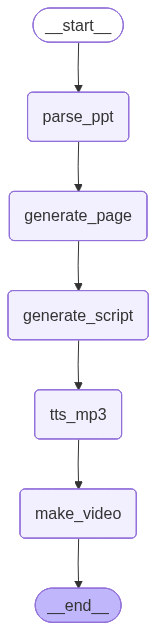

In [22]:
from langgraph.graph import StateGraph, END
builder = StateGraph(State)

# 노드 추가
builder.add_node("parse_ppt", node_parse_ppt)
builder.add_node("generate_page", node_generate_text)
builder.add_node("generate_script", node_generate_script)
builder.add_node("tts_mp3", node_tts)
builder.add_node("make_video", node_make_video)

# 노드 연결
builder.add_edge(START, "parse_ppt")
builder.add_edge("parse_ppt", "generate_page")
builder.add_edge("generate_page", "generate_script")
builder.add_edge("generate_script", "tts_mp3")
builder.add_edge("tts_mp3", "make_video")
builder.add_edge("make_video", END)

# 컴파일
app = builder.compile()

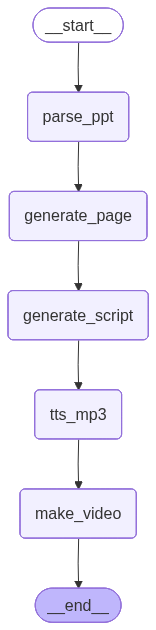

In [23]:
app

## **4. 시스템 실행**

미션1,2에서 수행한 결과를 통합 테스트 해 봅시다.

### (1) 준비 작업
* 파일 업로드
* 사용자 프롬프트 준비

In [24]:
# 파일 업로드 (1page PPTX)
pptx_path = "./data/sample1.pptx"

In [25]:
# 파일 업로드 (1page image)
slide_image_path = "./data/sample1.png"

In [26]:
# 사용자 프롬프트
USER_PROMPT = {
	"voice": "alloy",
	"tone": "친절하고 명료한 강의 톤",
	"style": "예시와 핵심 요점 중심"
}
# 출력 dir 만들기
WORK_DIR = "./step1_output"
MEDIA_DIR = "./step1_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) Agent 실행
* State 초기화
* app 실행
* 동영상 play

In [27]:
state: State = {
	"pptx_path": pptx_path,
	"slide_image": [slide_image_path],
	"prompt": USER_PROMPT,
	"work_dir": WORK_DIR,
	"media_dir": MEDIA_DIR,
}

In [28]:
# 전체 그래프 실행
state = app.invoke(state)

# 영상 재생
video_path = state['slides'][0].video

with open(video_path, "rb") as f:
	data = f.read()
display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

[INFO] Page 0: 텍스트 13개, 표 1개, 이미지 1개 추출 완료.
[INFO] 총 1 슬라이드 처리 완료.
[INFO] Page 0 요약 생성 완료.
[INFO] Page 0 스크립트 생성 완료.
[INFO] Page 0 음성 생성 완료: ./step1_output/media/0_tts.mp3 (70.06 sec)
[INFO] page 0 영상 생성 완료: ./step1_output/media/slide0.mp4


In [29]:
import gradio as gr

def play_video():
    return video_path

demo = gr.Interface(
    fn=play_video,
    inputs=[],
    outputs=gr.Video(),
    title="영상 재생"
)

demo.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
